# DBSCAN

In [1]:
# Import libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

In [2]:
# Check current working directory

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\E_Commerce_Customer_Segmentation\research


In [3]:
# Load transformed data

rfm = pd.read_csv("../artifacts/data_transformation/customer_rfm.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
# Check data shape

print("Shape:", rfm.shape)

Shape: (4338, 4)


In [5]:
# Check columns

print("Columns:", rfm.columns.tolist())

Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [6]:
# Check missing values

print(rfm.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


In [7]:
# Separate customer ID and features

customer_ids = rfm["CustomerID"]

X = rfm[["Recency", "Frequency", "Monetary"]]

print("Customer IDs shape:", customer_ids.shape)
print("Features shape:", X.shape)

Customer IDs shape: (4338,)
Features shape: (4338, 3)


# Data Preprocessing

In [8]:
# Check skewness

print(X.skew())

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [9]:
# Apply log transformation

X_log = np.log1p(X)

X_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [10]:
# Check skewness after log transformation

print(X_log.skew())

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64


In [11]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [12]:
# Scale features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_log.columns,
    index=X_log.index
)

X_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [13]:
# Check scaled features

print("Mean:")
print(X_scaled.mean())

print("\nStandard Deviation:")
print(X_scaled.std())

Mean:
Recency     -8.025955e-17
Frequency   -8.189750e-18
Monetary    -3.734526e-16
dtype: float64

Standard Deviation:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


# Baseline DBSCAN

In [14]:
# Baseline DBSCAN

baseline_dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

baseline_labels = baseline_dbscan.fit_predict(
    X_scaled
)

In [15]:
# Add baseline cluster labels

rfm["Baseline_Cluster"] = baseline_labels

rfm["Baseline_Cluster"].value_counts().sort_index()

Baseline_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64

In [16]:
# Count clusters and noise

baseline_noise_count = (
    baseline_labels == -1
).sum()

baseline_noise_percentage = (
    baseline_noise_count / len(baseline_labels)
) * 100

baseline_cluster_count = len(
    set(baseline_labels)
    - {-1}
)

print("Number of clusters:", baseline_cluster_count)

print("Noise points:", baseline_noise_count)

print(
    f"Noise percentage: "
    f"{baseline_noise_percentage:.2f}%"
)

Number of clusters: 2
Noise points: 62
Noise percentage: 1.43%


In [17]:
# Baseline evaluation

baseline_mask = baseline_labels != -1

baseline_X = X_scaled[baseline_mask]
baseline_cluster_labels = baseline_labels[baseline_mask]

baseline_unique_clusters = np.unique(
    baseline_cluster_labels
)

if len(baseline_unique_clusters) >= 2:

    baseline_silhouette = silhouette_score(
        baseline_X,
        baseline_cluster_labels
    )

    baseline_davies_bouldin = davies_bouldin_score(
        baseline_X,
        baseline_cluster_labels
    )

    baseline_calinski = calinski_harabasz_score(
        baseline_X,
        baseline_cluster_labels
    )

else:

    baseline_silhouette = np.nan
    baseline_davies_bouldin = np.nan
    baseline_calinski = np.nan

In [18]:
print("Baseline DBSCAN Evaluation")

print(
    f"Silhouette Score: "
    f"{baseline_silhouette:.4f}"
)

print(
    f"Davies-Bouldin Index: "
    f"{baseline_davies_bouldin:.4f}"
)

print(
    f"Calinski-Harabasz Score: "
    f"{baseline_calinski:.2f}"
)

print(
    f"Number of Clusters: "
    f"{baseline_cluster_count}"
)

print(
    f"Noise Percentage: "
    f"{baseline_noise_percentage:.2f}%"
)

Baseline DBSCAN Evaluation
Silhouette Score: 0.2930
Davies-Bouldin Index: 1.0636
Calinski-Harabasz Score: 2390.20
Number of Clusters: 2
Noise Percentage: 1.43%


In [19]:
# Check baseline cluster distribution

rfm["Baseline_Cluster"].value_counts().sort_index()

Baseline_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64

In [20]:
# Find candidate eps using k-distance

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(
    X_scaled
)

In [21]:
# Sort distances to the kth nearest neighbor

k_distances = np.sort(
    distances[:, -1]
)

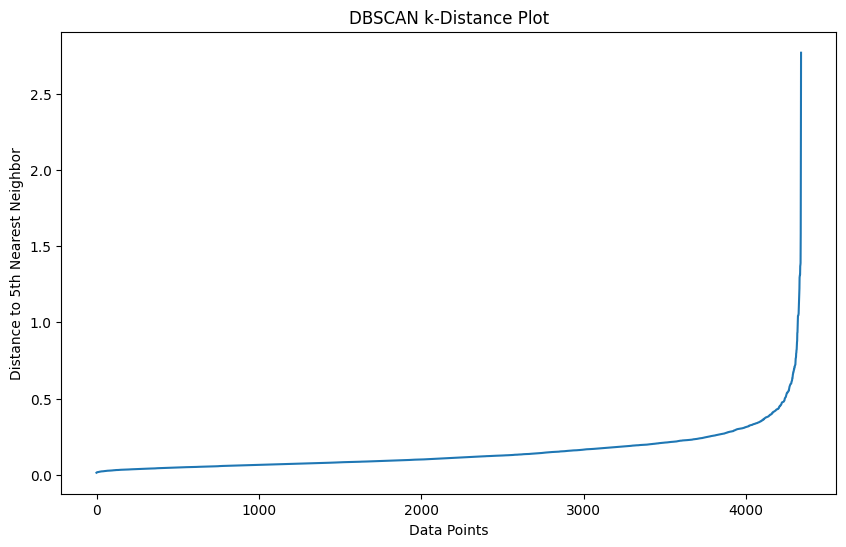

In [22]:
# Plot k-distance curve

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Data Points")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("DBSCAN k-Distance Plot")

plt.show()

# Hyperparameter Tuning Experiment

In [23]:
# Define experiment values

eps_values = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    1.0
]

min_samples_values = [
    3,
    5,
    10
]

In [24]:
# Create experiment results list

experiment_results = []

In [25]:
# Run DBSCAN experiments

for eps in eps_values:

    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        noise_mask = labels == -1

        noise_count = noise_mask.sum()

        noise_percentage = (
            noise_count / len(labels)
        ) * 100

        cluster_mask = labels != -1

        cluster_labels = labels[cluster_mask]

        cluster_X = X_scaled[cluster_mask]

        unique_clusters = np.unique(
            cluster_labels
        )

        cluster_count = len(
            unique_clusters
        )

        if cluster_count >= 2:

            silhouette = silhouette_score(
                cluster_X,
                cluster_labels
            )

            davies_bouldin = davies_bouldin_score(
                cluster_X,
                cluster_labels
            )

            calinski_harabasz = calinski_harabasz_score(
                cluster_X,
                cluster_labels
            )

        else:

            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan

        experiment_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": cluster_count,
            "noise_percentage": noise_percentage,
            "silhouette_score": silhouette,
            "davies_bouldin_score": davies_bouldin,
            "calinski_harabasz_score": calinski_harabasz
        })

In [26]:
# Create experiment results DataFrame

experiment_results_df = pd.DataFrame(
    experiment_results
)

experiment_results_df

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,0.2,3,58,9.497464,-0.100314,1.012115,153.956109
1,0.2,5,32,14.591978,-0.030324,1.161747,241.529778
2,0.2,10,14,29.967727,0.073591,1.549137,330.311681
3,0.3,3,16,3.757492,-0.038715,1.065879,416.380205
4,0.3,5,8,5.693868,0.062705,1.506098,829.205920
5,0.3,10,6,10.258183,0.088472,1.708174,1130.892409
6,0.4,3,8,1.613647,0.088483,0.974644,621.467819
7,0.4,5,6,2.305210,0.067326,1.166193,848.183469
8,0.4,10,3,3.826648,0.174751,1.688955,2079.211653
9,0.5,3,5,1.060396,0.250568,0.853681,638.582414


In [27]:
# View experiments sorted by silhouette score

experiment_results_df.sort_values(
    "silhouette_score",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
15,0.7,3,2,0.484094,0.633538,0.292059,41.205696
13,0.6,5,2,0.760719,0.566971,0.347982,50.340796
16,0.7,5,2,0.599355,0.564035,0.349621,49.587201
12,0.6,3,4,0.507146,0.536889,0.654610,46.925893
11,0.5,10,2,1.821116,0.293912,1.061745,2393.228502
10,0.5,5,2,1.429230,0.293022,1.063614,2390.196438
9,0.5,3,5,1.060396,0.250568,0.853681,638.582414
8,0.4,10,3,3.826648,0.174751,1.688955,2079.211653
6,0.4,3,8,1.613647,0.088483,0.974644,621.467819
5,0.3,10,6,10.258183,0.088472,1.708174,1130.892409


In [28]:
# View experiments sorted by Davies-Bouldin Index

experiment_results_df.sort_values(
    "davies_bouldin_score",
    ascending=True
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
15,0.7,3,2,0.484094,0.633538,0.292059,41.205696
13,0.6,5,2,0.760719,0.566971,0.347982,50.340796
16,0.7,5,2,0.599355,0.564035,0.349621,49.587201
12,0.6,3,4,0.507146,0.536889,0.654610,46.925893
9,0.5,3,5,1.060396,0.250568,0.853681,638.582414
6,0.4,3,8,1.613647,0.088483,0.974644,621.467819
0,0.2,3,58,9.497464,-0.100314,1.012115,153.956109
11,0.5,10,2,1.821116,0.293912,1.061745,2393.228502
10,0.5,5,2,1.429230,0.293022,1.063614,2390.196438
3,0.3,3,16,3.757492,-0.038715,1.065879,416.380205


In [29]:
# View experiments sorted by Calinski-Harabasz Score

experiment_results_df.sort_values(
    "calinski_harabasz_score",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
11,0.5,10,2,1.821116,0.293912,1.061745,2393.228502
10,0.5,5,2,1.429230,0.293022,1.063614,2390.196438
8,0.4,10,3,3.826648,0.174751,1.688955,2079.211653
5,0.3,10,6,10.258183,0.088472,1.708174,1130.892409
7,0.4,5,6,2.305210,0.067326,1.166193,848.183469
4,0.3,5,8,5.693868,0.062705,1.506098,829.205920
9,0.5,3,5,1.060396,0.250568,0.853681,638.582414
6,0.4,3,8,1.613647,0.088483,0.974644,621.467819
3,0.3,3,16,3.757492,-0.038715,1.065879,416.380205
2,0.2,10,14,29.967727,0.073591,1.549137,330.311681


In [30]:
# View experiments sorted by noise percentage

experiment_results_df.sort_values(
    "noise_percentage",
    ascending=True
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
21,1.0,3,1,0.207469,NaN,NaN,NaN
22,1.0,5,1,0.230521,NaN,NaN,NaN
23,1.0,10,1,0.276625,NaN,NaN,NaN
18,0.8,3,1,0.368834,NaN,NaN,NaN
15,0.7,3,2,0.484094,0.633538,0.292059,41.205696
19,0.8,5,1,0.484094,NaN,NaN,NaN
12,0.6,3,4,0.507146,0.536889,0.654610,46.925893
16,0.7,5,2,0.599355,0.564035,0.349621,49.587201
20,0.8,10,1,0.668511,NaN,NaN,NaN
13,0.6,5,2,0.760719,0.566971,0.347982,50.340796


In [31]:
# Analyze effect of eps

eps_experiment = (
    experiment_results_df
    .groupby("eps")[
        [
            "n_clusters",
            "noise_percentage",
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score"
        ]
    ]
    .mean()
    .round(4)
)

eps_experiment

,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
eps,,,,,
0.2,34.6667,18.0191,-0.0190,1.2410,241.9325
0.3,10.0000,6.5698,0.0375,1.4267,792.1595
0.4,5.6667,2.5818,0.1102,1.2766,1182.9543
0.5,3.0000,1.4369,0.2792,0.9930,1807.3358
0.6,2.3333,0.8068,0.5519,0.5013,48.6333
0.7,1.6667,0.6608,0.5988,0.3208,45.3964
0.8,1.0000,0.5071,NaN,NaN,NaN
1.0,1.0000,0.2382,NaN,NaN,NaN


In [32]:
# Analyze effect of min_samples

min_samples_experiment = (
    experiment_results_df
    .groupby("min_samples")[
        [
            "n_clusters",
            "noise_percentage",
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score"
        ]
    ]
    .mean()
    .round(4)
)

min_samples_experiment

,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
min_samples,,,,,
3,11.875,2.1871,0.2284,0.8088,319.7530
5,6.750,3.2619,0.2540,0.9325,734.8406
10,3.625,6.1088,0.1577,1.5020,1483.4111


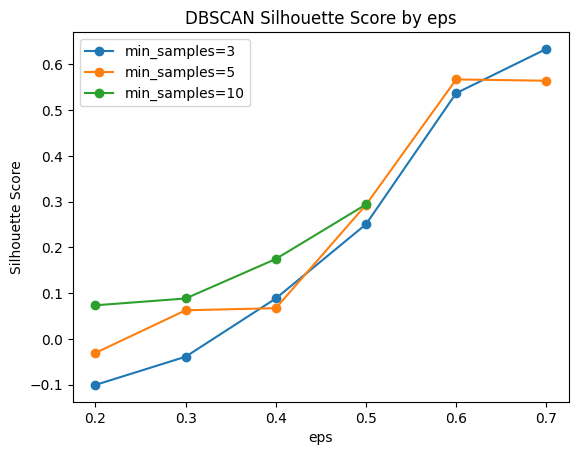

In [33]:
# Plot silhouette scores

for min_samples in min_samples_values:

    subset = experiment_results_df[
        experiment_results_df["min_samples"] == min_samples
    ]

    plt.plot(
        subset["eps"],
        subset["silhouette_score"],
        marker="o",
        label=f"min_samples={min_samples}"
    )

plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Silhouette Score by eps")
plt.legend()
plt.show()

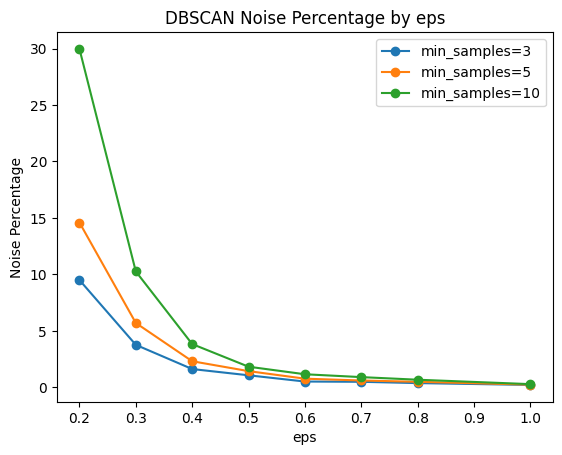

In [34]:
# Plot noise percentage

for min_samples in min_samples_values:

    subset = experiment_results_df[
        experiment_results_df["min_samples"] == min_samples
    ]

    plt.plot(
        subset["eps"],
        subset["noise_percentage"],
        marker="o",
        label=f"min_samples={min_samples}"
    )

plt.xlabel("eps")
plt.ylabel("Noise Percentage")
plt.title("DBSCAN Noise Percentage by eps")
plt.legend()
plt.show()

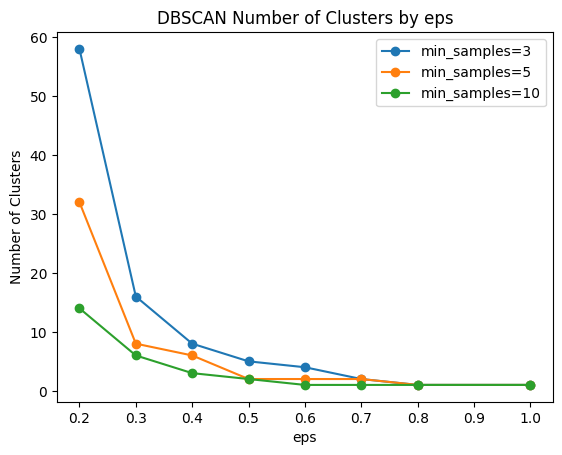

In [35]:
# Plot number of clusters

for min_samples in min_samples_values:

    subset = experiment_results_df[
        experiment_results_df["min_samples"] == min_samples
    ]

    plt.plot(
        subset["eps"],
        subset["n_clusters"],
        marker="o",
        label=f"min_samples={min_samples}"
    )

plt.xlabel("eps")
plt.ylabel("Number of Clusters")
plt.title("DBSCAN Number of Clusters by eps")
plt.legend()
plt.show()

# Hyperparameter Tuning

In [36]:
# Define tuning parameters

tuning_eps_values = [
    0.50,
    0.52,
    0.54,
    0.56,
    0.58,
    0.60,
    0.62,
    0.64,
    0.66,
    0.68,
    0.70
]

tuning_min_samples_values = [
    3,
    4,
    5,
    6,
    7
]

In [37]:
# Create tuning results list

tuning_results = []

In [38]:
# Run DBSCAN hyperparameter tuning

for eps in tuning_eps_values:

    for min_samples in tuning_min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        noise_mask = labels == -1

        noise_count = noise_mask.sum()

        noise_percentage = (
            noise_count / len(labels)
        ) * 100

        cluster_mask = labels != -1

        cluster_X = X_scaled[
            cluster_mask
        ]

        cluster_labels = labels[
            cluster_mask
        ]

        unique_clusters = np.unique(
            cluster_labels
        )

        cluster_count = len(
            unique_clusters
        )

        if cluster_count >= 2:

            silhouette = silhouette_score(
                cluster_X,
                cluster_labels
            )

            davies_bouldin = davies_bouldin_score(
                cluster_X,
                cluster_labels
            )

            calinski_harabasz = calinski_harabasz_score(
                cluster_X,
                cluster_labels
            )

        else:

            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan

        tuning_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": cluster_count,
            "noise_percentage": noise_percentage,
            "silhouette_score": silhouette,
            "davies_bouldin_score": davies_bouldin,
            "calinski_harabasz_score": calinski_harabasz
        })

In [56]:
# Create tuning results DataFrame

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df.head()

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,0.5,3,5,1.060396,0.250568,0.853681,638.582414
1,0.5,4,3,1.198709,0.257312,0.823616,1229.164566
2,0.5,5,2,1.429230,0.293022,1.063614,2390.196438
3,0.5,6,3,1.475334,0.216777,0.857318,1203.678629
4,0.5,7,2,1.613647,0.293568,1.063805,2391.541363


In [40]:
# View tuning results by silhouette score

tuning_results_df.sort_values(
    "silhouette_score",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
40,0.66,3,2,0.484094,0.633538,0.292059,41.205696
50,0.70,3,2,0.484094,0.633538,0.292059,41.205696
45,0.68,3,2,0.484094,0.633538,0.292059,41.205696
27,0.60,5,2,0.760719,0.566971,0.347982,50.340796
32,0.62,5,2,0.737667,0.566647,0.348154,50.272213
26,0.60,4,2,0.714615,0.566210,0.348396,50.158948
31,0.62,4,2,0.691563,0.565822,0.348611,50.064483
37,0.64,5,2,0.691563,0.565785,0.348650,50.035116
36,0.64,4,2,0.668511,0.565348,0.348893,49.922924
41,0.66,4,2,0.645459,0.564928,0.349117,49.823417


In [41]:
# Filter excessive noise

valid_results_df = tuning_results_df[
    (tuning_results_df["noise_percentage"] <= 30) &
    (tuning_results_df["n_clusters"] >= 2)
].copy()

valid_results_df.sort_values(
    "silhouette_score",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
40,0.66,3,2,0.484094,0.633538,0.292059,41.205696
50,0.70,3,2,0.484094,0.633538,0.292059,41.205696
45,0.68,3,2,0.484094,0.633538,0.292059,41.205696
27,0.60,5,2,0.760719,0.566971,0.347982,50.340796
32,0.62,5,2,0.737667,0.566647,0.348154,50.272213
26,0.60,4,2,0.714615,0.566210,0.348396,50.158948
31,0.62,4,2,0.691563,0.565822,0.348611,50.064483
37,0.64,5,2,0.691563,0.565785,0.348650,50.035116
36,0.64,4,2,0.668511,0.565348,0.348893,49.922924
41,0.66,4,2,0.645459,0.564928,0.349117,49.823417


In [42]:
# Check cluster balance

balanced_results = []

for _, result in valid_results_df.iterrows():

    model = DBSCAN(
        eps=result["eps"],
        min_samples=int(result["min_samples"])
    )

    labels = model.fit_predict(X_scaled)

    cluster_labels = labels[
        labels != -1
    ]

    cluster_sizes = pd.Series(
        cluster_labels
    ).value_counts()

    if len(cluster_sizes) >= 2:

        min_cluster_percentage = (
            cluster_sizes.min()
            / cluster_sizes.sum()
        ) * 100

        if min_cluster_percentage >= 5:

            result["min_cluster_percentage"] = (
                min_cluster_percentage
            )

            balanced_results.append(result)

In [43]:
# Create balanced tuning results

balanced_results_df = pd.DataFrame(
    balanced_results
)

balanced_results_df.sort_values(
    "silhouette_score",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score,min_cluster_percentage
4,0.50,7.0,2.0,1.613647,0.293568,1.063805,2391.541363,34.746954
9,0.52,7.0,2.0,1.521438,0.293451,1.063533,2392.479152,34.714419
2,0.50,5.0,2.0,1.429230,0.293022,1.063614,2390.196438,34.728718
14,0.54,7.0,2.0,1.290917,0.292970,1.062232,2393.665214,34.656702
8,0.52,6.0,2.0,1.360074,0.292952,1.063511,2390.810809,34.704370
7,0.52,5.0,2.0,1.290917,0.292866,1.063259,2391.959643,34.680056
13,0.54,6.0,2.0,1.198709,0.292826,1.062952,2393.522753,34.671022
12,0.54,5.0,2.0,1.175657,0.292799,1.062829,2394.063875,34.662934
19,0.56,7.0,2.0,1.244813,0.292758,1.062967,2391.867329,34.663866
18,0.56,6.0,2.0,1.152605,0.292748,1.062651,2394.464189,34.654851


In [44]:
# Select best valid configuration

best_result = balanced_results_df.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

best_result

eps                           0.500000
min_samples                   7.000000
n_clusters                    2.000000
noise_percentage              1.613647
silhouette_score              0.293568
davies_bouldin_score          1.063805
calinski_harabasz_score    2391.541363
min_cluster_percentage       34.746954
Name: 4, dtype: float64

In [45]:
# Display best parameters

print("Best DBSCAN Configuration")

print(
    f"eps: {best_result['eps']}"
)

print(
    f"min_samples: "
    f"{int(best_result['min_samples'])}"
)

print(
    f"Number of Clusters: "
    f"{int(best_result['n_clusters'])}"
)

print(
    f"Noise Percentage: "
    f"{best_result['noise_percentage']:.2f}%"
)

print(
    f"Minimum Cluster Percentage: "
    f"{best_result['min_cluster_percentage']:.2f}%"
)

Best DBSCAN Configuration
eps: 0.5
min_samples: 7
Number of Clusters: 2
Noise Percentage: 1.61%
Minimum Cluster Percentage: 34.75%


In [46]:
# Create tuned DBSCAN

tuned_dbscan = DBSCAN(
    eps=best_result["eps"],
    min_samples=int(
        best_result["min_samples"]
    )
)

tuned_labels = tuned_dbscan.fit_predict(
    X_scaled
)

In [47]:
# Evaluate tuned DBSCAN

tuned_noise_count = (
    tuned_labels == -1
).sum()

tuned_noise_percentage = (
    tuned_noise_count / len(tuned_labels)
) * 100

tuned_cluster_count = len(
    set(tuned_labels) - {-1}
)

tuned_mask = tuned_labels != -1

tuned_X = X_scaled[
    tuned_mask
]

tuned_cluster_labels = tuned_labels[
    tuned_mask
]

tuned_silhouette = silhouette_score(
    tuned_X,
    tuned_cluster_labels
)

tuned_davies_bouldin = davies_bouldin_score(
    tuned_X,
    tuned_cluster_labels
)

tuned_calinski = calinski_harabasz_score(
    tuned_X,
    tuned_cluster_labels
)

In [48]:
# Print tuned evaluation results

print("Tuned DBSCAN Evaluation")

print(
    f"Silhouette Score: "
    f"{tuned_silhouette:.4f}"
)

print(
    f"Davies-Bouldin Index: "
    f"{tuned_davies_bouldin:.4f}"
)

print(
    f"Calinski-Harabasz Score: "
    f"{tuned_calinski:.2f}"
)

print(
    f"Number of Clusters: "
    f"{tuned_cluster_count}"
)

print(
    f"Noise Percentage: "
    f"{tuned_noise_percentage:.2f}%"
)

Tuned DBSCAN Evaluation
Silhouette Score: 0.2936
Davies-Bouldin Index: 1.0638
Calinski-Harabasz Score: 2391.54
Number of Clusters: 2
Noise Percentage: 1.61%


# Baseline vs Tuned

In [49]:
# Compare baseline and tuned models

comparison = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score",
        "Number of Clusters",
        "Noise Percentage"
    ],
    "Baseline": [
        baseline_silhouette,
        baseline_davies_bouldin,
        baseline_calinski,
        baseline_cluster_count,
        baseline_noise_percentage
    ],
    "Tuned": [
        tuned_silhouette,
        tuned_davies_bouldin,
        tuned_calinski,
        tuned_cluster_count,
        tuned_noise_percentage
    ]
})

comparison

,Metric,Baseline,Tuned
0,Silhouette Score,0.293022,0.293568
1,Davies-Bouldin Index,1.063614,1.063805
2,Calinski-Harabasz Score,2390.196438,2391.541363
3,Number of Clusters,2.000000,2.000000
4,Noise Percentage,1.429230,1.613647


In [50]:
# Add tuned cluster labels

rfm["Cluster"] = tuned_labels

rfm["Cluster"].value_counts().sort_index()

Cluster
-1      70
 0    2785
 1    1483
Name: count, dtype: int64

In [51]:
# Create cluster profile

cluster_profile = (
    rfm[rfm["Cluster"] != -1]
    .groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

cluster_profile["CustomerCount"] = (
    rfm[rfm["Cluster"] != -1]
    .groupby("Cluster")
    .size()
)

cluster_profile["Percentage"] = (
    cluster_profile["CustomerCount"]
    / cluster_profile["CustomerCount"].sum()
    * 100
).round(2)

cluster_profile

,Recency,Frequency,Monetary,CustomerCount,Percentage
Cluster,,,,,
0,59.25,5.33,1976.25,2785,65.25
1,156.95,1.00,351.27,1483,34.75


In [52]:
# Sort clusters by monetary value

cluster_profile.sort_values(
    "Monetary",
    ascending=False
)

,Recency,Frequency,Monetary,CustomerCount,Percentage
Cluster,,,,,
0,59.25,5.33,1976.25,2785,65.25
1,156.95,1.00,351.27,1483,34.75


In [53]:
# Save tuning results

tuning_results_df.to_csv(
    "../artifacts/data_transformation/dbscan_tuning_results.csv",
    index=False
)

In [54]:
# Save customer cluster assignments

rfm.to_csv(
    "../artifacts/data_transformation/customer_clusters_dbscan.csv",
    index=False
)

In [55]:
# Save cluster profile

cluster_profile.to_csv(
    "../artifacts/data_transformation/dbscan_cluster_profile.csv"
)

# Key Insights

DBSCAN clustering was successfully applied to the customer-level RFM data after log transformation and feature scaling.

The baseline DBSCAN model produced 2 clusters with a noise percentage of 1.43%. The baseline Silhouette Score was 0.2930, while the Davies-Bouldin Index was 1.0636 and the Calinski-Harabasz Score was 2390.20.

Hyperparameter experiments were performed by varying eps and min_samples. The experiments showed that clustering quality improved considerably for higher eps values, with some configurations achieving higher Silhouette Scores but producing less balanced cluster distributions.

A separate tuning stage was performed with noise and cluster-balance constraints. The selected tuned configuration was eps = 0.5 and min_samples = 7, producing 2 clusters with 1.61% noise and a minimum cluster percentage of 34.75%.

The tuned model produced a Silhouette Score of 0.2936, Davies-Bouldin Index of 1.0638, and Calinski-Harabasz Score of 2391.54. The tuned results were very similar to the baseline results, indicating that the baseline configuration was already close to a reasonable configuration under the selected constraints.

The final cluster profile showed two distinct customer groups. Cluster 0 contained 65.25% of customers and had lower Recency, higher Frequency, and higher Monetary values. Cluster 1 contained 34.75% of customers and had higher Recency, lower Frequency, and lower Monetary values.

DBSCAN is considered as one candidate clustering algorithm for the final customer segmentation solution. Its results will be compared with K-Means, Hierarchical Clustering, and Gaussian Mixture Model before selecting the final model.